In [3]:
# -*- coding: utf-8 -*-
"""
Created on Fri Sep 20 14:23:31 2024
@author: krane
"""
from  numpy import *
import  matplotlib.pyplot as plt
from PoissonSolverwT import PoissonSolver
import sympy as sym

x, y = sym.symbols('x,y')

### Introduction to the Diffusion Equation

Let $u \in C^2(\Omega)$, where $\Omega \subset \mathbb{R}^2$ is a bounded domain. The Laplacian of $u$ is

$$
\Delta u = u_{xx}+u_{yy}.
$$

The 2D diffusion equation is given by

$$
-\alpha\Delta u(x,y)+u(x,y)=f(x,y), \qquad (x,y)\in\Omega,
$$

with the boundary condition

$$
u(x,y)\big|_{\partial\Omega}=I(x,y).
$$

Here, $f(x,y)$ is a known source function, $I(x,y)$ specifies the boundary values, and $\alpha>0$ is a given diffusion parameter.

In [28]:
"--- To test the solve, define the solution here. Otherwise, modify the right-hand side function directly---"

""" Comment this block if no true solution can be given """
u      = sym.sin(x*y)  #This is the true solution, use sympy to differentiate
u_func = sym.lambdify((x, y), u)
a      = 1      #The constant alpha for the diffusion equation
f      = sym.simplify(-a*(sym.diff(u, x, x)+sym.diff(u, y, y))+u)
f_func = sym.lambdify((x, y), f) 
I      = u_func #The boundary condition

#f_func = lambda x,y: None # source function
#I      = lambda x,y: None # boundary condition

x0 = 0; xf = 5 # x domain
y0 = 0; yf = 5 # y domain

We proposed two different methods to solve this problem - where both methods rely on the same concept of finite difference method with an extension of adaptivity but with different weights. The default of the solver is the central difference method and turning this off (or setting the boolean variable to FALSE) will switch it to the inner product method. A detailed explanation about the methods can be found in the paper: [Adaptive Finite Difference Methods and Implementation in the Software DUNE](https://zenodo.org/records/22841990)

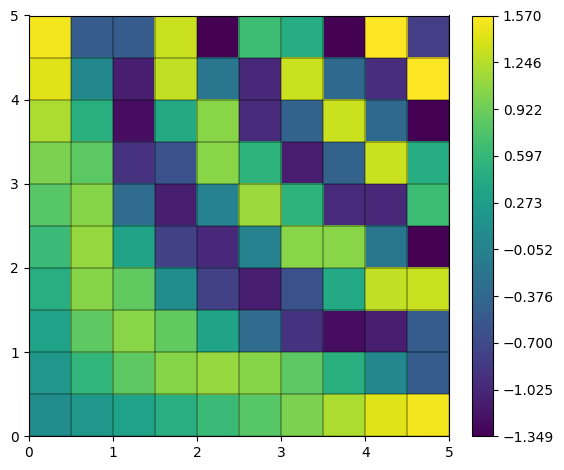

In [29]:
alpha = a
Nx    = 10 #Number of elements on the x-axis
Ny    = 10 #Number of elements on the y-axis

TestRefined = PoissonSolver(alpha, f_func, Nx, Ny, I=I,  Lx=x0, Rx=xf, Ly=y0, Ry=yf)
TestRefined.solver(central_difference=False)
TestRefined.plot()

#For plotting of true solution and error (if known)
#TestRefined.true_plot(u_func) 
#err=TestRefined.get_trueError(u_func)
#TestRefined.details(u)

# Adaptivity and Refinement Methods

### Local Error Refinement

The local error contribution of each element is defined as
$$
l_k=(u_k-\hat{u}_k)^2|e_k|.
$$
Here, $u_k$ is the exact solution, $\hat{u}_k$ is the numerical solution, and $|e_k|$ is the area of element $k$. Elements with $l_k>\varepsilon$ are marked for refinement, where $\varepsilon=\frac{E}{N},$ with $E$ the global error and $N$ the total number of elements. Refinement reduces the element size and aims to decrease its contribution to the global error. This method assumes that a finer grid improves the numerical solution.

### Max Error Refinement

Instead of refining all elements above a given error threshold, this method identifies the elements with the largest local error.
$$
l_{\max}=\max_k (u_k-\hat{u}_k)^2|e_k|.
$$
Elements close to $l_{\max}$ are collected in $M=\{e_k:\ |l_k-l_{\max}|\leq q\},$ where $q$ is a small tolerance. Only the elements in $M$ are refined, resulting in a small and targeted refinement of the grid.

### Second Derivative Refinement

This refinement method uses the Laplacian to identify regions of high curvature in the solution. The Laplacian measures how much a function value differs from the values of its surrounding points, with large magnitudes indicating stronger curvature.

The numerical Laplacian is computed as
$$
\Delta u_k = f_k-u_k-\alpha.
$$
The computed values are stored and used to identify regions with high positive or negative divergence, which are then targeted for refinement.

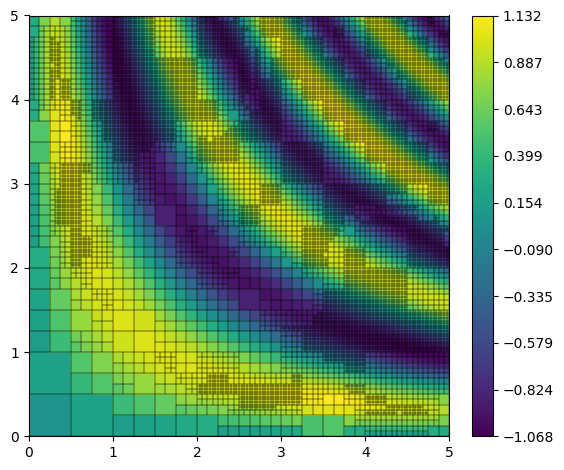

Function: sin(x*y)
Domain:(0 x 5) x (0 x 5)
Degrees of freedom: 10834
Error: 0.36565359463009933
Iterartion elapsed time: 0.78
Solution elapsed time: 0.1
Total elapsed time: 0.88



In [25]:
err=TestRefined.get_trueError(u_func)

marker = TestRefined.markh    #Local Error Refinement
#marker = TestRefined.markhmax #Max Error Refinement 
#marker = TestRefined.markhdiv #Second Derivative Refinement

TestRefined.solver(central_difference=False, markh=marker)
TestRefined.plot()
TestRefined.details(u)


#Run this code cell multiple times!
#Run the previous code cell to reset the grid!